<a href="https://colab.research.google.com/github/Sk-Kamrej/Bank_Marketing_Project/blob/main/Code/ADASYN_SHAP_%26_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ========================================================================
#  BANK MARKETING PROJECT (Machine Learning) Best 4 Models SHAP & LIME
# ========================================================================

In [2]:
# ==============================
# 1. INSTALL DEPENDENCIES
# ==============================

!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy scipy openpyxl shap lime

In [16]:
# ==============================
# 2. IMPORTS LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix)

from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import ADASYN

In [4]:
# ==============================
# 3. LOAD DATASET
# ==============================

df = pd.read_csv('/content/Bank_Marketing_Full.csv', sep=';')

In [5]:
# ==============================
# 4. PREPROCESSING
# ==============================

# Drop Leakage Feature
df = df.drop('duration', axis=1)

# Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [6]:
# ==============================
# 5. SPLIT DATA
# ==============================

# Split Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ADASYN Oversampling
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_scaled, y_train)

In [7]:
# ==============================
# 6. CROSS VALIDATION
# ==============================

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [28]:
# ==============================
# 7. CUSTOM UNIVERSAL FUNCTION
# ==============================
all_results = []

def evaluate_model(name, best_model):

    global all_results

    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_ad, y_train_ad)):

        X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
        y_tr, y_val = y_train_ad.iloc[train_idx], y_train_ad.iloc[val_idx]

        start = time.time()
        best_model.fit(X_tr, y_tr)
        training_time = time.time() - start

        y_pred = best_model.predict(X_val)
        y_prob = best_model.predict_proba(X_val)[:,1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        specificity = tn/(tn+fp) if (tn+fp) != 0 else 0
        recall = tp/(tp+fn) if (tp+fn) != 0 else 0

        results.append({
            "Fold": fold+1,
            "Classifier": name,
            "Accuracy": round(accuracy_score(y_val, y_pred), 4),
            "Precision": round(precision_score(y_val, y_pred, zero_division=0), 4),
            "Recall": round(recall, 4),
            "Specificity": round(specificity, 4),
            "F1 Score": round(f1_score(y_val, y_pred, zero_division=0), 4),
            "ROC-AUC": round(roc_auc_score(y_val, y_prob), 4),
            "MCC": round(matthews_corrcoef(y_val, y_pred), 4),
            "G-Mean": round(np.sqrt(recall * specificity), 4),
            "Kappa": round(cohen_kappa_score(y_val, y_pred), 4),
            "Balanced Accuracy": round((recall + specificity)/2, 4),
            "Training Time (s)": round(training_time, 4)
        })

    df_results = pd.DataFrame(results)

    # STORE RESULTS
    all_results.append(df_results)

    print(f"\nResults for {name}:")
    display(df_results)

    # ======================================================
    # SHAP + LIME (RUN ONLY ONCE AFTER TRAINING)
    # ======================================================
    print("# ==============================")
    print(f"# EXPLAINABILITY: {name}")
    print("# ==============================")

    # -----------------------------
    # Use scaled data
    # -----------------------------
    X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

    # FAST SAMPLING
    X_sample = X_test_df.sample(200, random_state=42)

    # ==============================
    # SHAP EXPLAINABILITY
    # ==============================

    print("\n# ==============================")
    print("# SHAP EXPLANATION")
    print("# ==============================\n")

    # -----------------------------
    # SHAP Explainer
    # -----------------------------
    explainer = shap.TreeExplainer(best_model, approximate=True)

    # Compute SHAP values
    shap_values = explainer.shap_values(X_sample)

    # Handling SHAP output formats for multi-class / binary classification
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
        expected_value = explainer.expected_value[1]

    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_vals = shap_values[:, :, 1]
        expected_value = explainer.expected_value[1]

    else:
        shap_vals = shap_values
        expected_value = explainer.expected_value

    # -------------------------------
    # 1. GLOBAL FEATURE IMPORTANCE
    # -------------------------------
    shap.summary_plot(
        shap_vals,
        X_sample,
        plot_type="bar",
        plot_size=(14, 10)
    )

    # -------------------------------
    # 2. DETAILED SUMMARY PLOT
    # -------------------------------
    shap.summary_plot(
        shap_vals,
        X_sample,
        plot_size=(14, 10)
    )

    # -------------------------------
    # 3. DEPENDENCE PLOT
    # -------------------------------
    plt.figure(figsize=(12, 6))
    shap.dependence_plot(
        X_sample.columns[0],
        shap_vals,
        X_sample
    )

    # -------------------------------
    # 4. LOCAL EXPLANATION (CLEAN FORCE PLOT)
    # -------------------------------
    plt.figure(figsize=(16, 4))

    shap.force_plot(
        expected_value,
        shap_vals[0],
        X_sample.iloc[0],
        matplotlib=True,
        contribution_threshold=0.05
    )

    # ==============================
    # LIME EXPLAINABILITY
    # ==============================

    print("\n# ==============================")
    print("# LIME EXPLANATION")
    print("# ==============================\n")

    # -----------------------------
    # Use SAME data format (scaled)
    # -----------------------------
    X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

    # -----------------------------
    # Create LIME Explainer
    # -----------------------------
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_df.values,
        feature_names=X.columns.tolist(),
        class_names=["No", "Yes"],
        mode="classification"
    )

    # -----------------------------
    # Explain ONE instance
    # -----------------------------
    exp = explainer_lime.explain_instance(
        X_test_df.values[0],
        best_model.predict_proba
    )

    # -----------------------------
    # COLORFUL PLOT
    # -----------------------------
    fig = exp.as_pyplot_figure()

    fig.set_size_inches(10, 6)
    plt.title("LIME Feature Contribution", fontsize=14)

    plt.show()

# MODEL: Random Forest

Best parameters: {'n_estimators': 200, 'max_depth': 20}
Best CV accuracy: 0.9373
Test accuracy: 0.8917
Total Training Time: 10 min 50 sec

Results for Random Forest:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Random Forest,0.9379,0.9494,0.9250,0.9508,0.9370,0.9804,0.8760,0.9378,0.8757,0.9379,18.5515
1,2,Random Forest,0.9380,0.9478,0.9270,0.9490,0.9373,0.9804,0.8763,0.9380,0.8761,0.9380,19.0692
2,3,Random Forest,0.9350,0.9415,0.9273,0.9425,0.9344,0.9809,0.8700,0.9349,0.8699,0.9349,18.1544
3,4,Random Forest,0.9391,0.9485,0.9284,0.9497,0.9383,0.9780,0.8783,0.9390,0.8781,0.9391,18.1213
4,5,Random Forest,0.9355,0.9431,0.9267,0.9443,0.9348,0.9799,0.8711,0.9354,0.8709,0.9355,18.7049
5,6,Random Forest,0.9392,0.9498,0.9273,0.9511,0.9384,0.9822,0.8787,0.9391,0.8785,0.9392,16.6783
6,7,Random Forest,0.9389,0.9514,0.9249,0.9528,0.9380,0.9837,0.8781,0.9388,0.8778,0.9389,16.9351
7,8,Random Forest,0.9291,0.9347,0.9225,0.9357,0.9286,0.9778,0.8583,0.9291,0.8583,0.9291,17.6810
8,9,Random Forest,0.9384,0.9469,0.9287,0.9480,0.9377,0.9808,0.8769,0.9383,0.8768,0.9384,17.4532
9,10,Random Forest,0.9387,0.9460,0.9305,0.9470,0.9382,0.9817,0.8776,0.9387,0.8774,0.9387,17.8284


# ==============================
# EXPLAINABILITY: Random Forest
# ==============================

# ==============================
# SHAP EXPLANATION
# ==============================



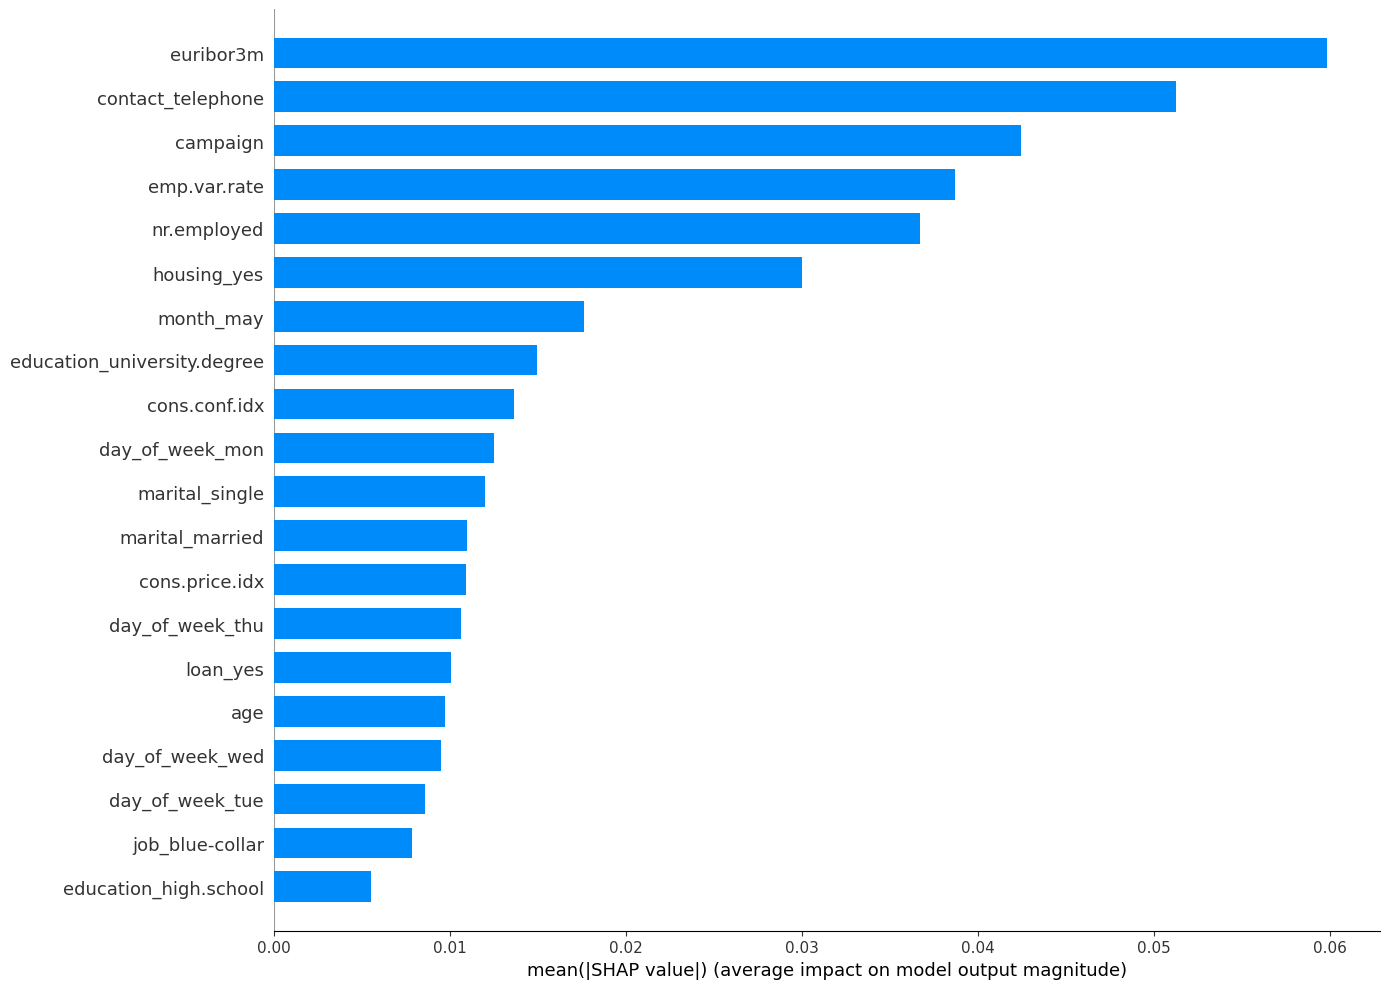

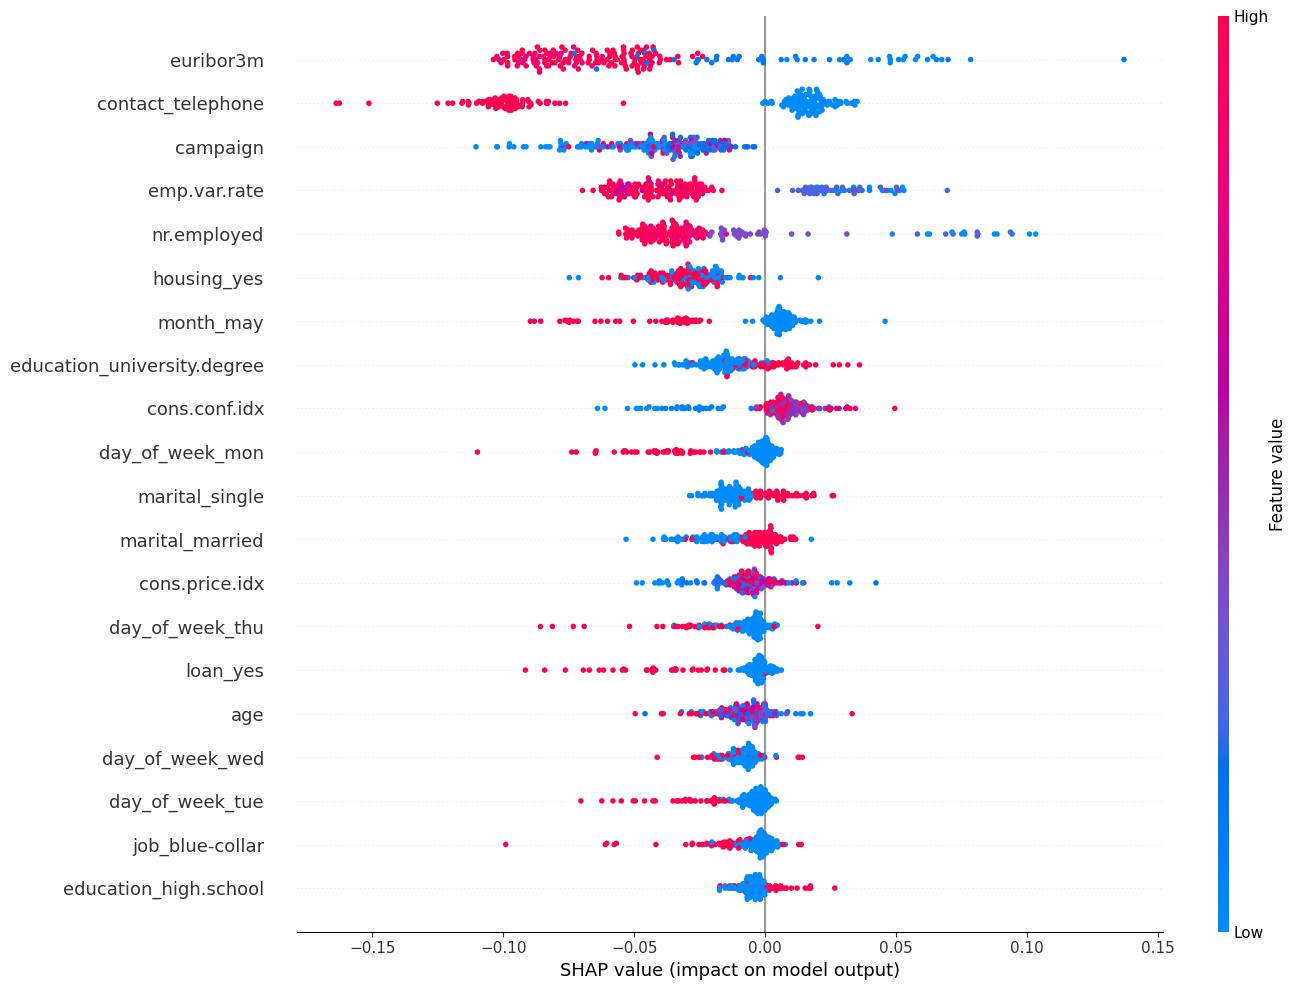

<Figure size 1200x600 with 0 Axes>

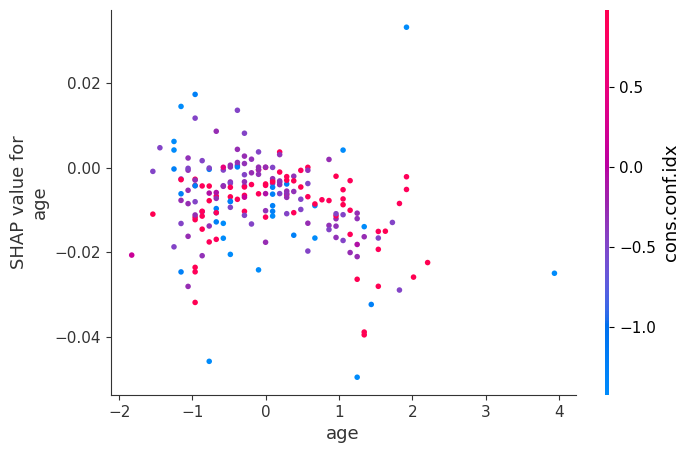

<Figure size 1600x400 with 0 Axes>

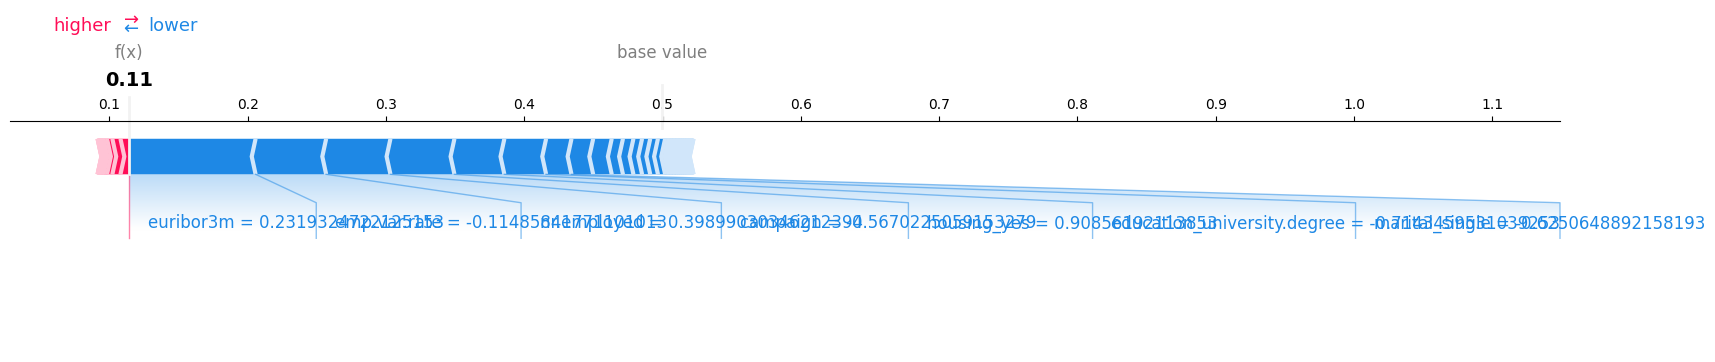


# ==============================
# LIME EXPLANATION
# ==============================



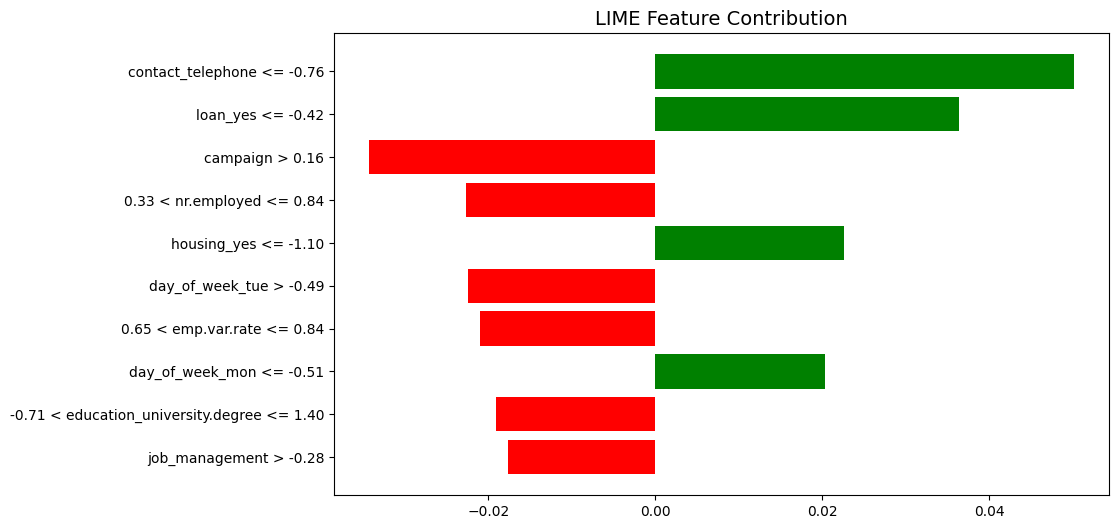

In [29]:
# ==============================
# MODEL: Random Forest
# ==============================
from sklearn.ensemble import RandomForestClassifier

# Base Model
model = RandomForestClassifier()

# Parameter grid
params = {
    "n_estimators":[200,300],
    "max_depth":[10,20]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=10, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Random Forest", best_model)

# MODEL: XGBoost

Best parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
Best CV accuracy: 0.9341
Test accuracy: 0.9023
Total Training Time: 6 min 25 sec

Results for XGBoost:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,XGBoost,0.9310,0.9736,0.8859,0.9761,0.9277,0.9732,0.8656,0.9299,0.8620,0.9310,9.2381
1,2,XGBoost,0.9339,0.9717,0.8938,0.9740,0.9311,0.9718,0.8707,0.9330,0.8679,0.9339,6.5642
2,3,XGBoost,0.9329,0.9661,0.8972,0.9685,0.9303,0.9725,0.8680,0.9322,0.8658,0.9329,8.8663
3,4,XGBoost,0.9319,0.9709,0.8903,0.9733,0.9289,0.9701,0.8667,0.9309,0.8637,0.9318,7.9495
4,5,XGBoost,0.9336,0.9651,0.8996,0.9675,0.9312,0.9734,0.8692,0.9329,0.8672,0.9335,6.6252
5,6,XGBoost,0.9367,0.9736,0.8975,0.9757,0.9340,0.9754,0.8760,0.9358,0.8733,0.9366,10.3154
6,7,XGBoost,0.9351,0.9728,0.8951,0.9750,0.9324,0.9771,0.8730,0.9342,0.8702,0.9351,6.6380
7,8,XGBoost,0.9308,0.9683,0.8907,0.9709,0.9279,0.9704,0.8645,0.9299,0.8617,0.9308,8.8860
8,9,XGBoost,0.9374,0.9776,0.8952,0.9795,0.9345,0.9744,0.8778,0.9364,0.8747,0.9373,8.4054
9,10,XGBoost,0.9374,0.9698,0.9027,0.9719,0.9351,0.9748,0.8768,0.9367,0.8747,0.9373,6.9289


# ==============================
# EXPLAINABILITY: XGBoost
# ==============================

# ==============================
# SHAP EXPLANATION
# ==============================



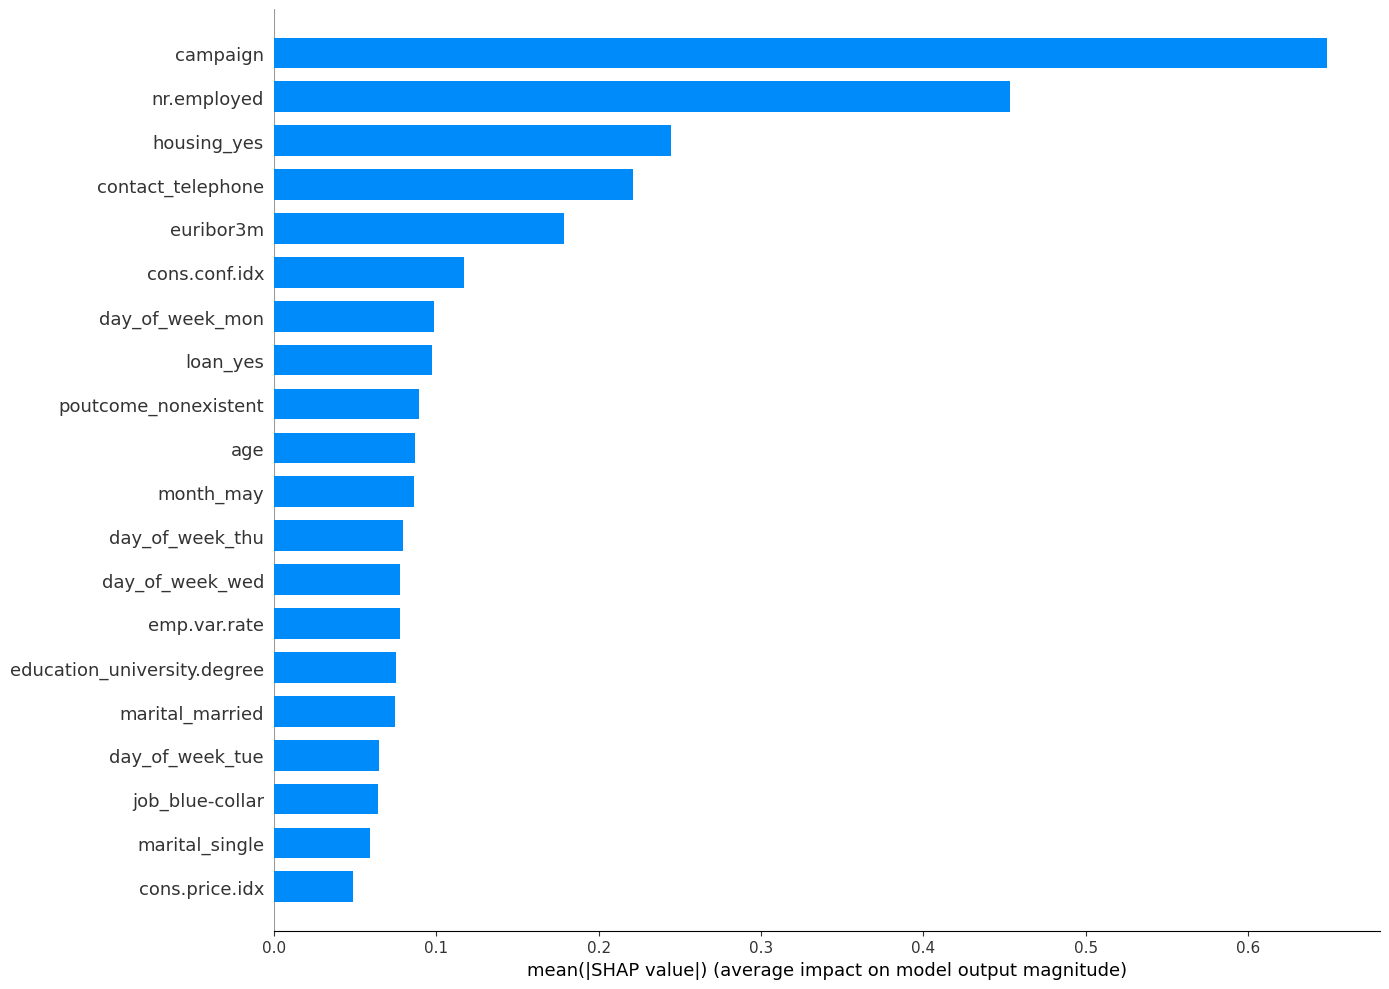

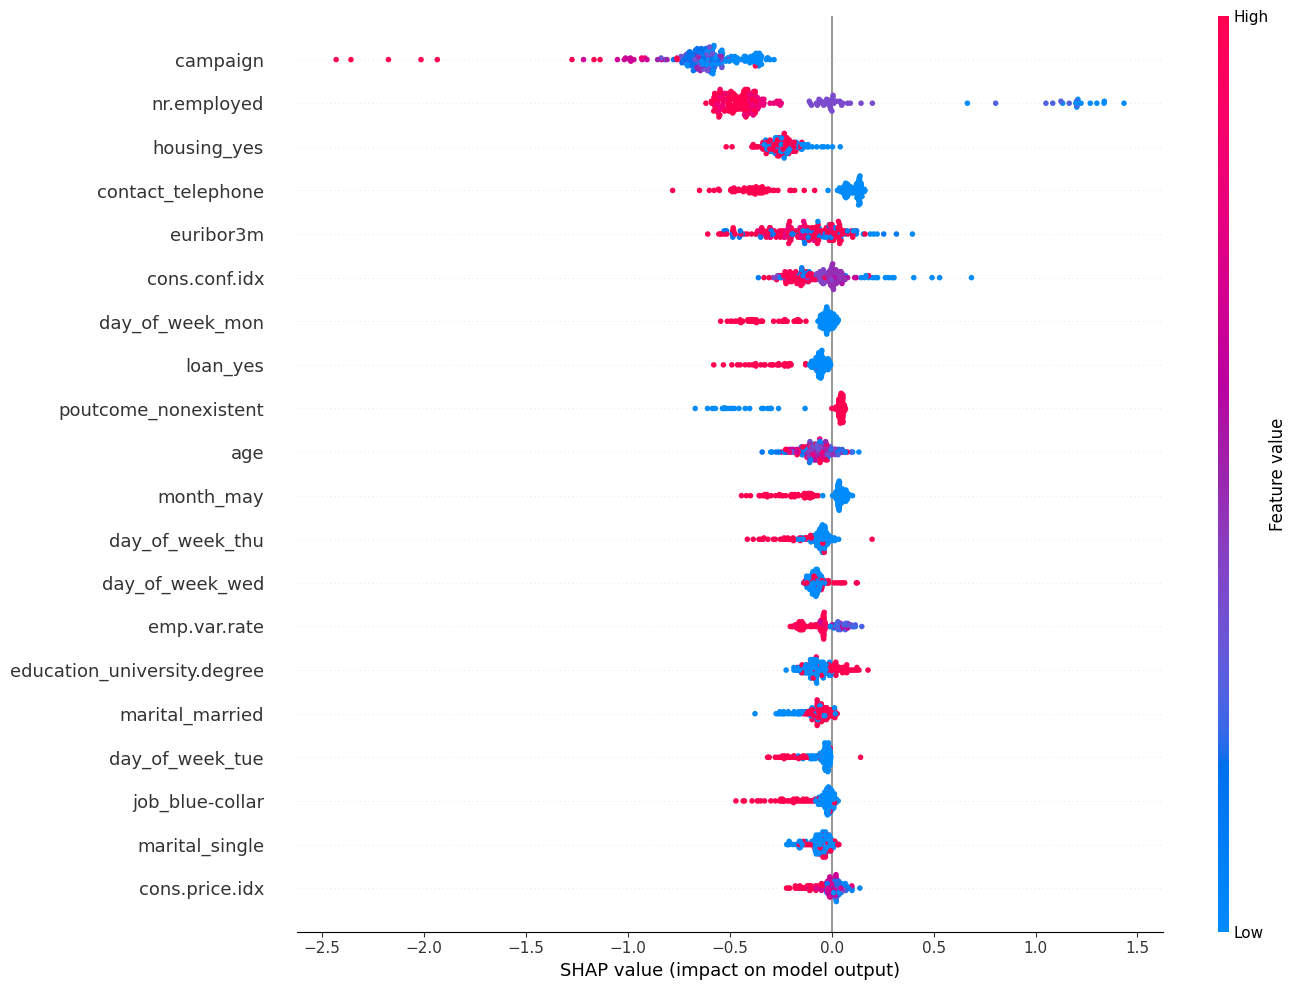

<Figure size 1200x600 with 0 Axes>

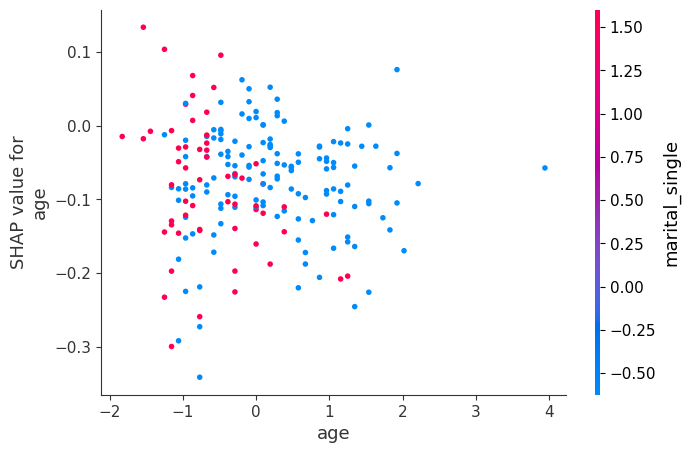

<Figure size 1600x400 with 0 Axes>

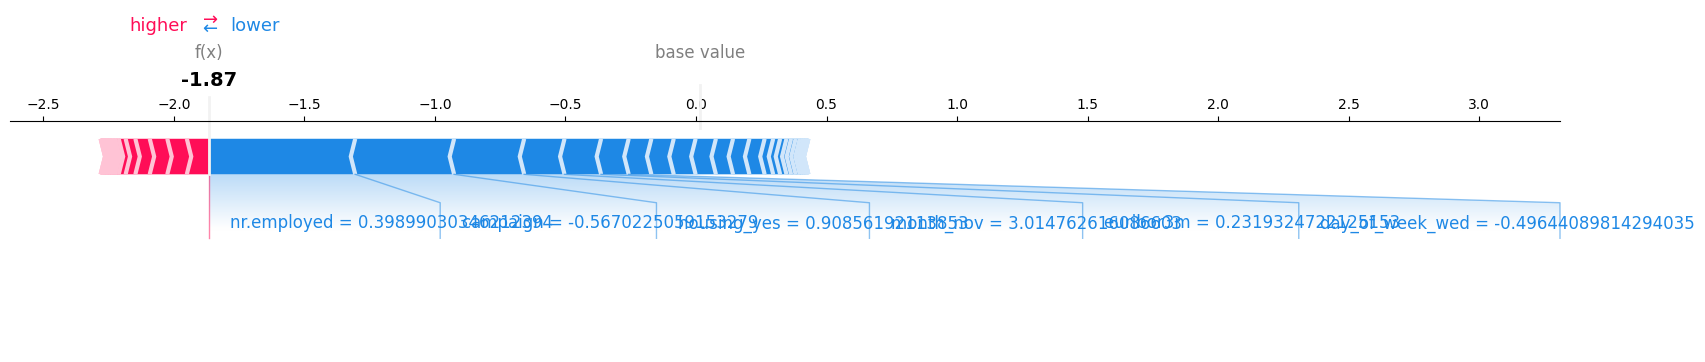


# ==============================
# LIME EXPLANATION
# ==============================



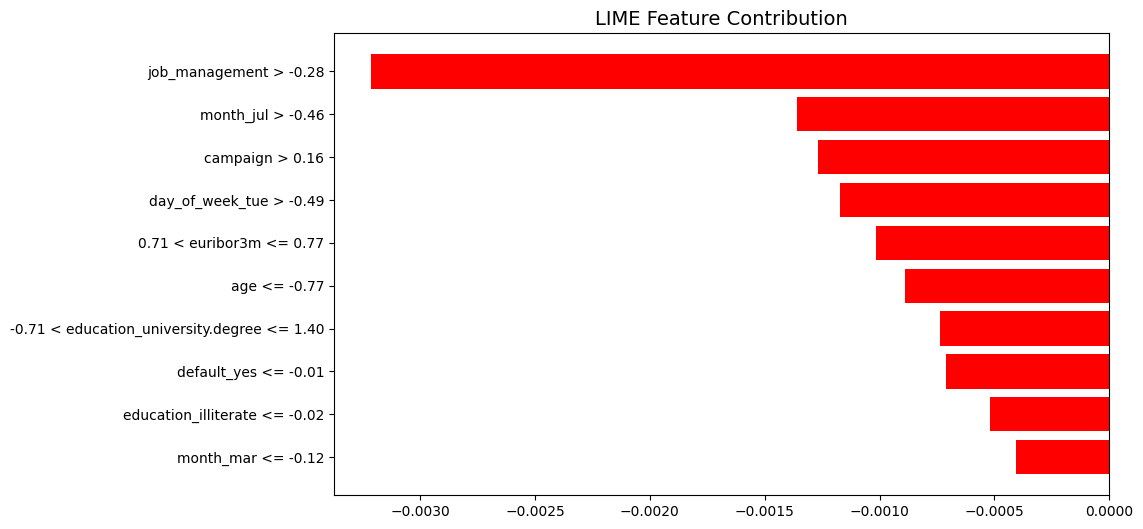

In [23]:
# ==============================
# MODEL: XGBoost
# ==============================
from xgboost import XGBClassifier

# Base Model
model = XGBClassifier(eval_metric='logloss')

# Parameter grid
params = {
    "n_estimators":[300,500],
    "learning_rate":[0.03,0.05],
    "max_depth":[3,5]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("XGBoost", best_model)

# MODEL: LightGBM

Best parameters: {'n_estimators': 500, 'learning_rate': 0.05}
Best CV accuracy: 0.9391
Test accuracy: 0.9013
Total Training Time: 3 min 27 sec

Results for LightGBM:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,LightGBM,0.9379,0.9783,0.8955,0.9802,0.9351,0.9758,0.8789,0.9369,0.8757,0.9378,6.1626
1,2,LightGBM,0.9382,0.9741,0.9003,0.9761,0.9357,0.9739,0.8789,0.9374,0.8764,0.9382,4.9690
2,3,LightGBM,0.9384,0.9671,0.9075,0.9692,0.9364,0.9740,0.8784,0.9378,0.8767,0.9383,6.3233
3,4,LightGBM,0.9389,0.9737,0.9020,0.9757,0.9365,0.9722,0.8802,0.9381,0.8778,0.9389,5.1281
4,5,LightGBM,0.9389,0.9685,0.9071,0.9706,0.9368,0.9757,0.8795,0.9383,0.8778,0.9389,6.3860
5,6,LightGBM,0.9411,0.9767,0.9037,0.9785,0.9388,0.9767,0.8847,0.9403,0.8822,0.9411,5.1440
6,7,LightGBM,0.9411,0.9728,0.9075,0.9747,0.9390,0.9783,0.8842,0.9405,0.8822,0.9411,6.3800
7,8,LightGBM,0.9334,0.9678,0.8965,0.9702,0.9308,0.9723,0.8692,0.9326,0.8668,0.9334,4.9208
8,9,LightGBM,0.9415,0.9785,0.9027,0.9802,0.9391,0.9760,0.8856,0.9406,0.8829,0.9414,5.4403
9,10,LightGBM,0.9415,0.9711,0.9099,0.9730,0.9395,0.9768,0.8847,0.9409,0.8829,0.9414,5.5942


# ==============================
# EXPLAINABILITY: LightGBM
# ==============================

# ==============================
# SHAP EXPLANATION
# ==============================



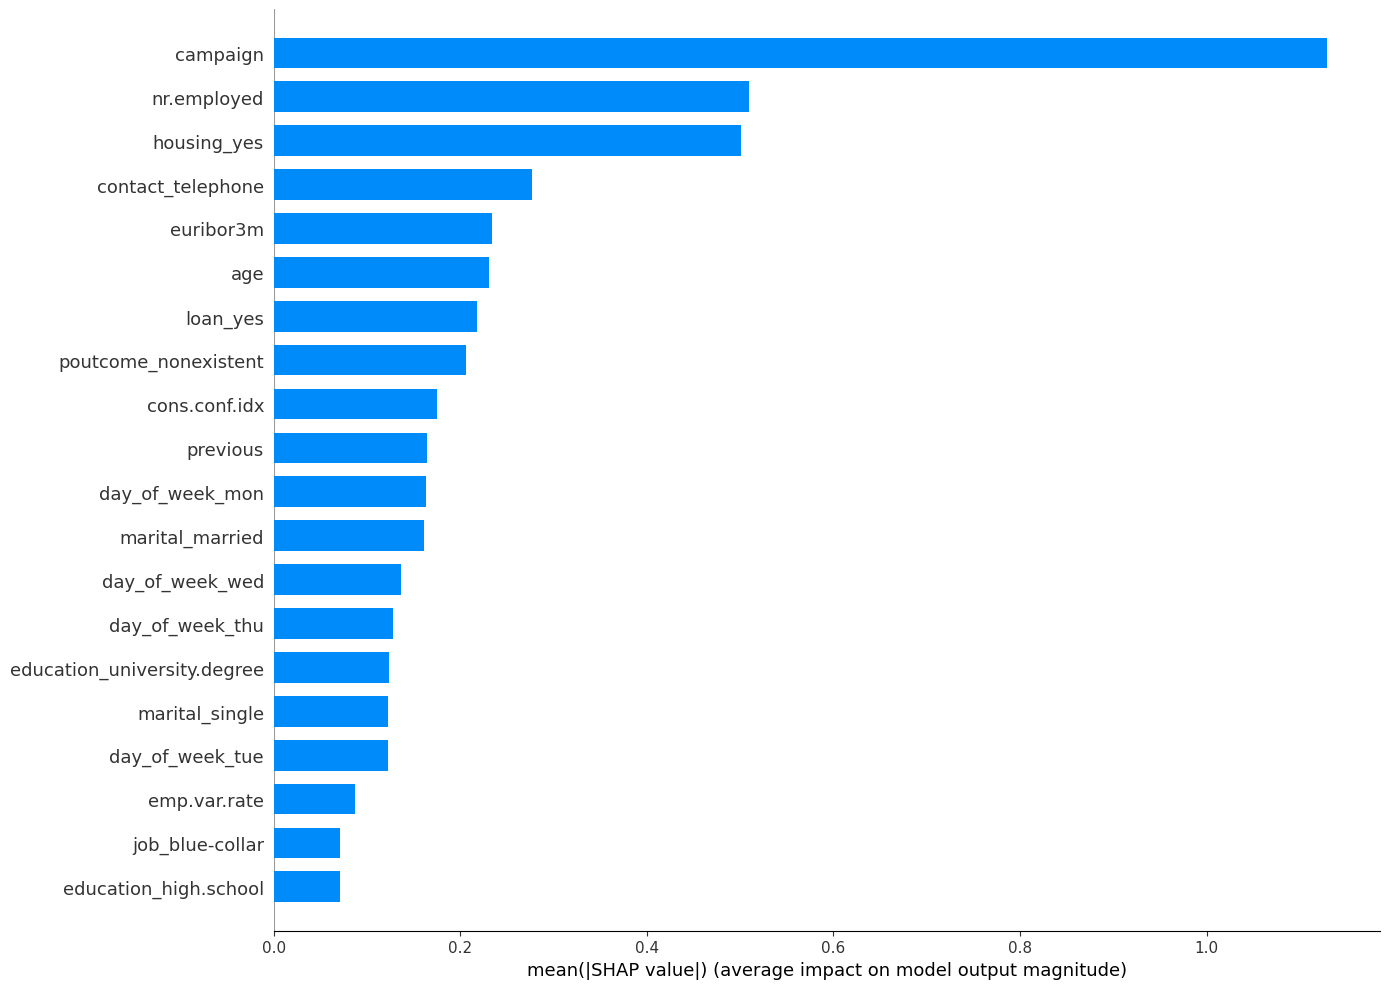

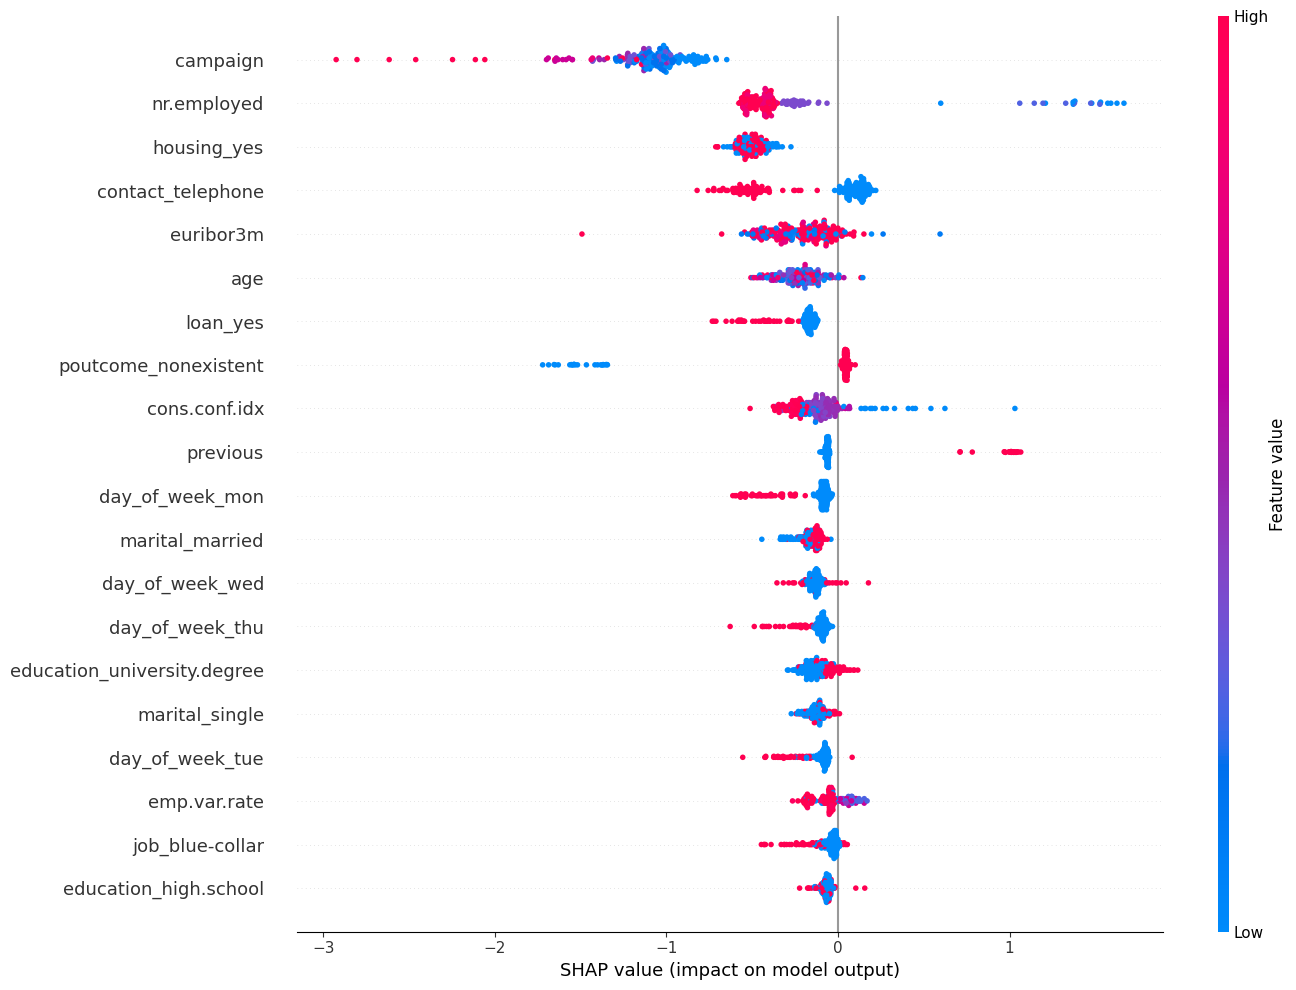

<Figure size 1200x600 with 0 Axes>

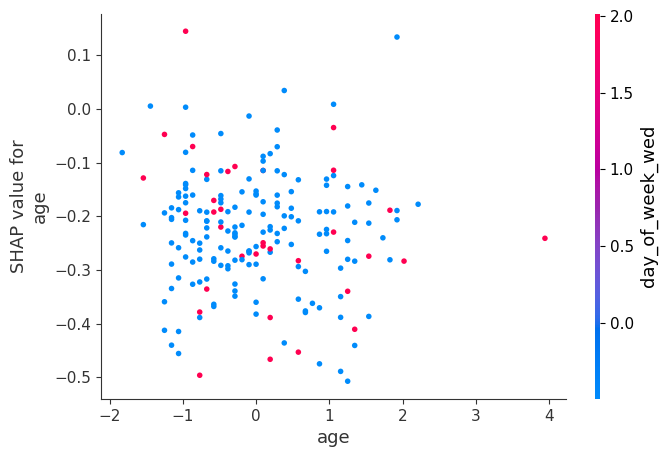

<Figure size 1600x400 with 0 Axes>

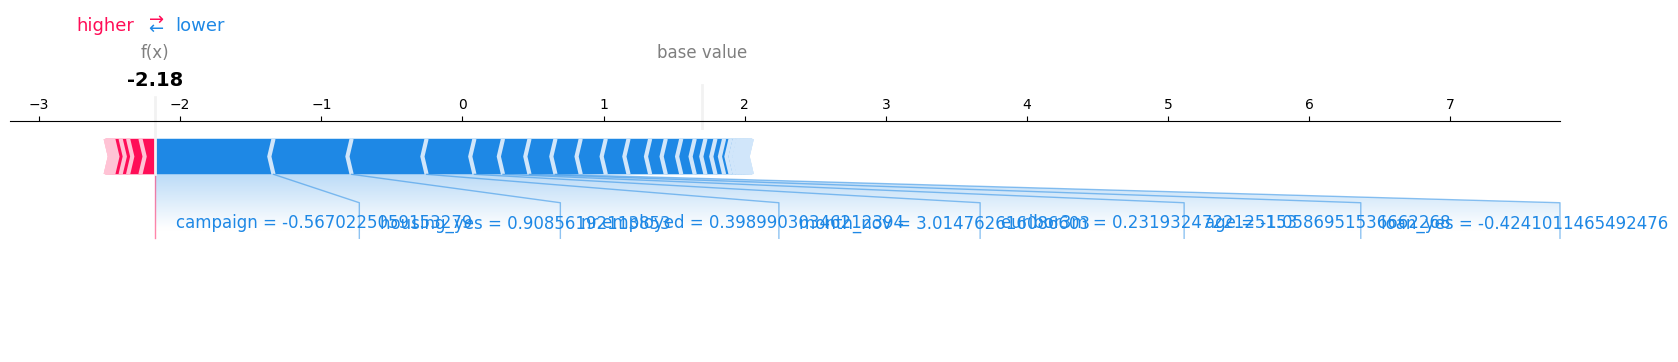


# ==============================
# LIME EXPLANATION
# ==============================



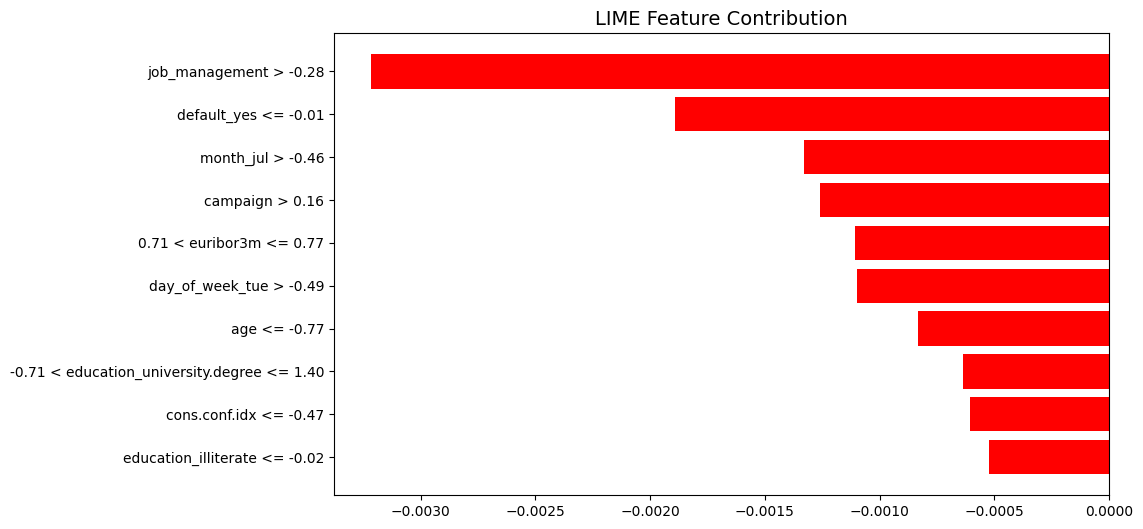

In [21]:
# ==============================
# MODEL: LightGBM
# ==============================
from lightgbm import LGBMClassifier

# Base Model
model = LGBMClassifier(verbosity=-1)

# Parameter grid
params = {
    "n_estimators":[300,500],
    "learning_rate":[0.03,0.05]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("LightGBM", best_model)

# MODEL: CatBoost

Best parameters: {'iterations': 300, 'depth': 6}
Best CV accuracy: 0.9382
Test accuracy: 0.9001
Total Training Time: 4 min 59 sec

Results for CatBoost:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,CatBoost,0.9334,0.9727,0.8917,0.9750,0.9305,0.9747,0.8699,0.9325,0.8668,0.9334,9.5276
1,2,CatBoost,0.9377,0.9740,0.8993,0.9761,0.9352,0.9732,0.8780,0.9369,0.8754,0.9377,8.1467
2,3,CatBoost,0.9382,0.9702,0.9040,0.9723,0.9360,0.9730,0.8784,0.9376,0.8764,0.9382,9.9273
3,4,CatBoost,0.9353,0.9721,0.8962,0.9744,0.9326,0.9714,0.8732,0.9344,0.8706,0.9353,9.7711
4,5,CatBoost,0.9385,0.9668,0.9082,0.9689,0.9366,0.9745,0.8787,0.9380,0.8771,0.9385,8.1568
5,6,CatBoost,0.9413,0.9760,0.9047,0.9778,0.9390,0.9759,0.8849,0.9405,0.8826,0.9412,9.8696
6,7,CatBoost,0.9401,0.9738,0.9044,0.9757,0.9378,0.9773,0.8824,0.9394,0.8802,0.9401,9.8820
7,8,CatBoost,0.9329,0.9661,0.8972,0.9685,0.9303,0.9716,0.8680,0.9322,0.8658,0.9329,14.8449
8,9,CatBoost,0.9397,0.9763,0.9013,0.9781,0.9373,0.9738,0.8821,0.9389,0.8795,0.9397,10.1759
9,10,CatBoost,0.9447,0.9734,0.9144,0.9750,0.9429,0.9763,0.8911,0.9442,0.8894,0.9447,8.3339


# ==============================
# EXPLAINABILITY: CatBoost
# ==============================

# ==============================
# SHAP EXPLANATION
# ==============================



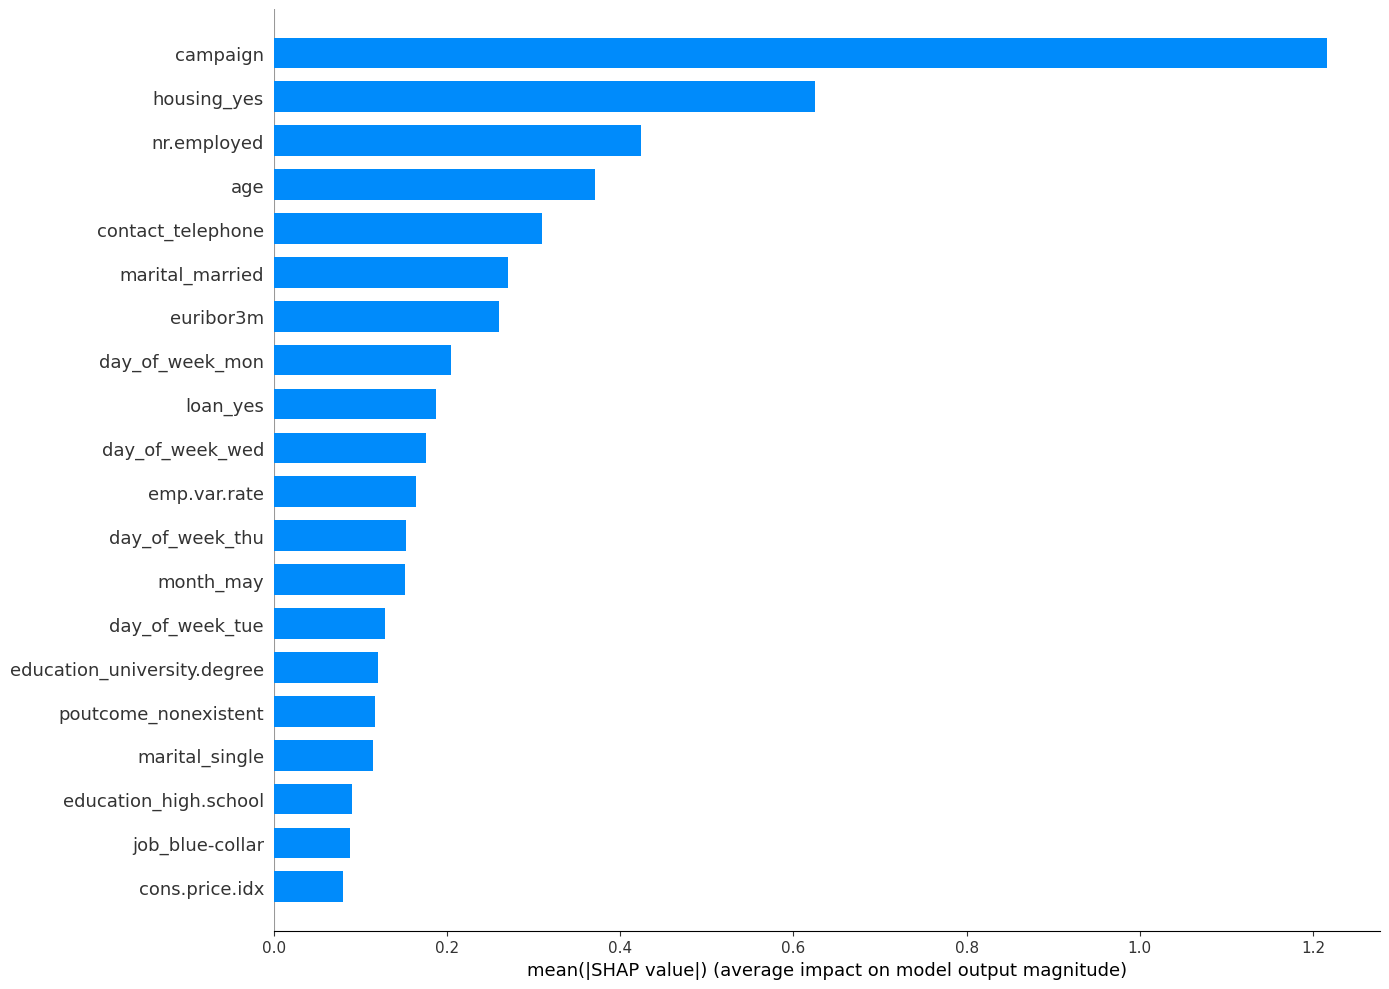

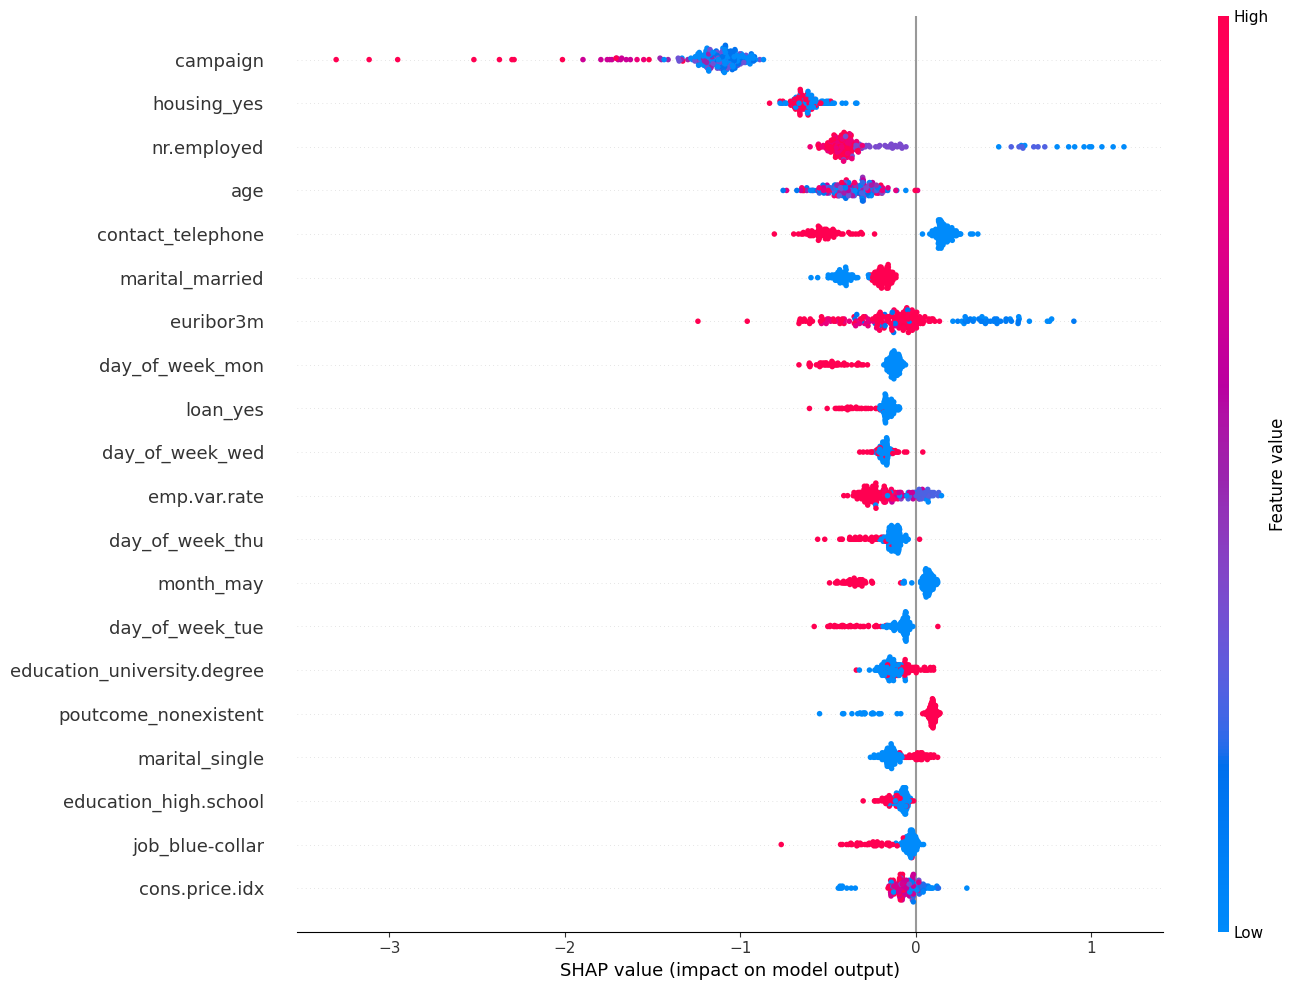

<Figure size 1200x600 with 0 Axes>

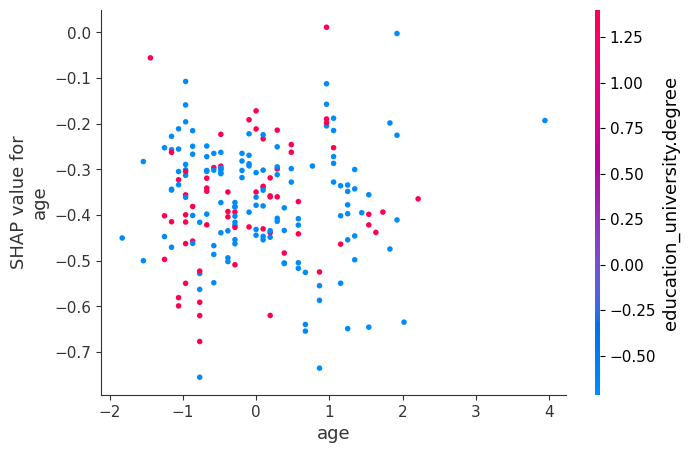

<Figure size 1600x400 with 0 Axes>

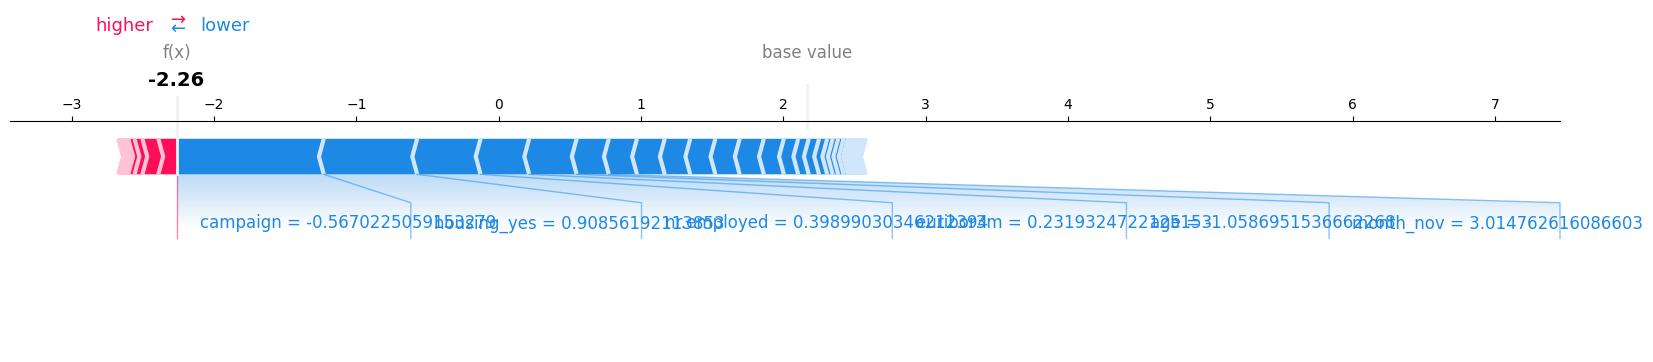


# ==============================
# LIME EXPLANATION
# ==============================



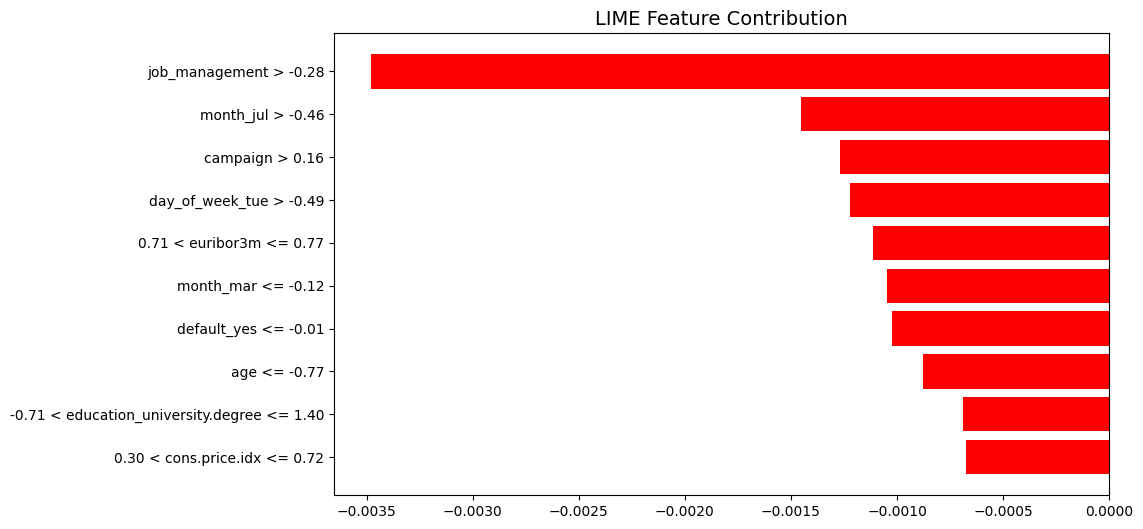

In [22]:
# ==============================
# MODEL: CatBoost
# ==============================
from catboost import CatBoostClassifier

# Base Model
model = CatBoostClassifier(verbose=0)

# Parameter grid
params = {
    "iterations":[200,300],
    "depth":[4,6]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("CatBoost", best_model)